In [1]:
# Install libraries if not already present
!pip install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


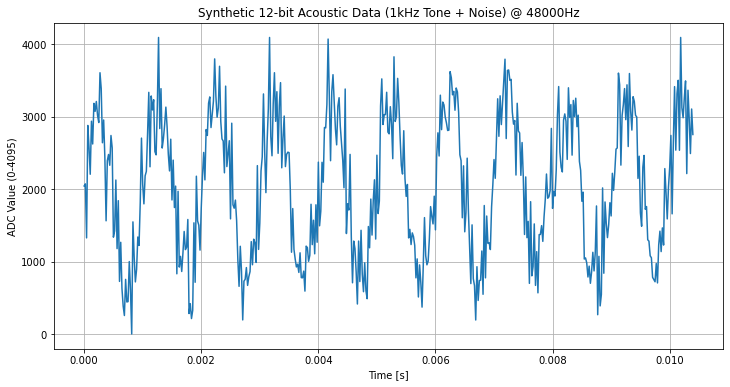

File 'input_signal.txt' created with 2400 samples.


In [2]:
# --- PARAMETERS ---
fs = 48000          # Sampling Frequency (48 kHz)
f_tone = 1000       # Target Acoustic Signal (1 kHz)
duration = 0.05     # Duration in seconds (enough for simulation)
bits = 12           # ADC Bit-depth (12-bit = 0 to 4095)

# 1. Create Time Vector
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# 2. Generate Clean Signal (Sine Wave)
# We use an amplitude of 0.6 to leave "headroom" for noise
clean_signal = 0.6 * np.sin(2 * np.pi * f_tone * t)

# 3. Generate Noise (High-frequency White Noise)
# We simulate a "noisy" environment with 0.2 amplitude
noise = 0.2 * np.random.normal(0, 1, len(t))

# 4. Mix Signal and Noise
raw_signal = clean_signal + noise

# 5. Quantization (Converting to Integers for FPGA)
# ADC hardware usually maps -1.0V to +1.0V to a range of 0 to 4095.
# We must shift the signal (add 1) to make it unipolar, then scale.
max_adc_val = (2**bits) - 1
quantized_signal = ((raw_signal + 1) / 2) * max_adc_val
quantized_signal = quantized_signal.astype(int)

# Ensure no values exceed 12-bit range due to noise spikes
quantized_signal = np.clip(quantized_signal, 0, max_adc_val)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.plot(t[:500], quantized_signal[:500]) # Plot first 500 samples
plt.title(f"Synthetic 12-bit Acoustic Data (1kHz Tone + Noise) @ {fs}Hz")
plt.xlabel("Time [s]")
plt.ylabel("ADC Value (0-4095)")
plt.grid(True)
plt.show()

# --- SAVE FOR VERILOG ---
# We save in Decimal format. Verilog's $readmemh can read Hex, 
# but for simplicity in early testing, we will save as a text list.
with open("input_signal.txt", "w") as f:
    for sample in quantized_signal:
        f.write(f"{sample}\n")

print(f"File 'input_signal.txt' created with {len(quantized_signal)} samples.")